In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,PowerTransformer,MinMaxScaler

Part A: Data Preprocessing Tasks

In [2]:
df=pd.read_csv("Retail_Transactions_2000.csv")
df.head()

,TransactionID,CustomerID,Gender,Age,City,ProductCategory,Quantity,Price,PurchaseDate,PaymentMode,TotalAmount
0,T00001,C2824,Female,33,Bengaluru,Fashion,3,4479,2023-03-15,Cash,13437
1,T00002,C1409,Other,20,Pune,Books,5,1051,2023-01-22,Card,5255
2,T00003,C5506,Other,47,Pune,Furniture,1,111,2023-04-18,Wallet,111
3,T00004,C5012,Other,21,Hyderabad,Groceries,5,2946,2023-08-09,Cash,14730
4,T00005,C4657,Female,41,Chennai,Sports,1,3123,2023-09-23,Wallet,3123


In [3]:
df.shape

(2000, 11)

In [4]:
df.columns

Index(['TransactionID', 'CustomerID', 'Gender', 'Age', 'City',
       'ProductCategory', 'Quantity', 'Price', 'PurchaseDate', 'PaymentMode',
       'TotalAmount'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   TransactionID    2000 non-null   object
 1   CustomerID       2000 non-null   object
 2   Gender           2000 non-null   object
 3   Age              2000 non-null   int64 
 4   City             2000 non-null   object
 5   ProductCategory  2000 non-null   object
 6   Quantity         2000 non-null   int64 
 7   Price            2000 non-null   int64 
 8   PurchaseDate     2000 non-null   object
 9   PaymentMode      2000 non-null   object
 10  TotalAmount      2000 non-null   int64 
dtypes: int64(4), object(7)
memory usage: 172.0+ KB


In [6]:
df.isnull().sum()

TransactionID      0
CustomerID         0
Gender             0
Age                0
City               0
ProductCategory    0
Quantity           0
Price              0
PurchaseDate       0
PaymentMode        0
TotalAmount        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Gender'] = df['Gender'].replace({
    'm':'Male','male':'Male','MALE':'Male', 
    'f':'Female','female':'Female','FEMALE':'Female',
    'other':'Other','o':'other','OTHER':'Other'})

In [9]:
print("Invalid Quantity (≤ 0):", df[df['Quantity'] <= 0].shape[0])
print("Invalid Price (≤ 0):", df[df['Price'] <= 0].shape[0])
print("Invalid TotalAmount (≤ 0):", df[df['TotalAmount'] <= 0].shape[0])

Invalid Quantity (≤ 0): 0
Invalid Price (≤ 0): 0
Invalid TotalAmount (≤ 0): 0


In [10]:
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'], errors='coerce')
df['Month'] = df['PurchaseDate'].dt.month_name()
df['DayOfWeek'] = df['PurchaseDate'].dt.day_name()
df.head()

,TransactionID,CustomerID,Gender,Age,City,ProductCategory,Quantity,Price,PurchaseDate,PaymentMode,TotalAmount,Month,DayOfWeek
0,T00001,C2824,Female,33,Bengaluru,Fashion,3,4479,2023-03-15,Cash,13437,March,Wednesday
1,T00002,C1409,Other,20,Pune,Books,5,1051,2023-01-22,Card,5255,January,Sunday
2,T00003,C5506,Other,47,Pune,Furniture,1,111,2023-04-18,Wallet,111,April,Tuesday
3,T00004,C5012,Other,21,Hyderabad,Groceries,5,2946,2023-08-09,Cash,14730,August,Wednesday
4,T00005,C4657,Female,41,Chennai,Sports,1,3123,2023-09-23,Wallet,3123,September,Saturday


In [11]:
bins = [17, 25, 40, 60, 100]
labels = ['Young Adult(18-25)', 'Adult(26-40)', 'Mid Age(41-60)', 'Senior(60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [12]:
df['AgeGroup'].value_counts()

AgeGroup
Mid Age(41-60)        791
Adult(26-40)          546
Senior(60+)           387
Young Adult(18-25)    276
Name: count, dtype: int64

In [13]:
df['City'].value_counts()

City
Ahmedabad    222
Bengaluru    217
Lucknow      213
Mumbai       202
Delhi        199
Jaipur       196
Kolkata      196
Chennai      187
Hyderabad    185
Pune         183
Name: count, dtype: int64

In [14]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  

df = pd.get_dummies(df, columns=['City'], drop_first=True)  

In [15]:
num_cols = ['Age','Quantity','Price','TotalAmount']
for col in num_cols:
    print(col, "skew:", df[col].skew())

Age skew: -0.07418375240160031
Quantity skew: 0.038834908156361474
Price skew: 0.04168211762662418
TotalAmount skew: 0.9087987587700852


In [16]:
pt = PowerTransformer(method='yeo-johnson')  
df['TotalAmount'] = pt.fit_transform(df[['TotalAmount']])
print(df['TotalAmount'].skew())

-0.07617384850884985


In [31]:
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [18]:
df.isnull().sum()

TransactionID      0
CustomerID         0
Gender             0
Age                0
ProductCategory    0
Quantity           0
Price              0
PurchaseDate       0
PaymentMode        0
TotalAmount        0
Month              0
DayOfWeek          0
AgeGroup           0
City_Bengaluru     0
City_Chennai       0
City_Delhi         0
City_Hyderabad     0
City_Jaipur        0
City_Kolkata       0
City_Lucknow       0
City_Mumbai        0
City_Pune          0
dtype: int64

Part B: Data Visualization Tasks

In [19]:
df.to_csv('Retail_Cleaned.csv', index=False)

In [20]:
df_clean=pd.read_csv("Retail_Cleaned.csv")
df_clean.head()

,TransactionID,CustomerID,Gender,Age,ProductCategory,Quantity,Price,PurchaseDate,PaymentMode,TotalAmount,...,AgeGroup,City_Bengaluru,City_Chennai,City_Delhi,City_Hyderabad,City_Jaipur,City_Kolkata,City_Lucknow,City_Mumbai,City_Pune
0,T00001,C2824,0,0.288462,Fashion,0.5,0.893673,2023-03-15,Cash,0.787964,...,Adult(26-40),True,False,False,False,False,False,False,False,False
1,T00002,C1409,2,0.038462,Books,1.0,0.194082,2023-01-22,Card,0.533344,...,Young Adult(18-25),False,False,False,False,False,False,False,False,True
2,T00003,C5506,2,0.557692,Furniture,0.0,0.002245,2023-04-18,Wallet,0.000000,...,Mid Age(41-60),False,False,False,False,False,False,False,False,True
3,T00004,C5012,2,0.057692,Groceries,1.0,0.580816,2023-08-09,Cash,0.816989,...,Young Adult(18-25),False,False,False,True,False,False,False,False,False
4,T00005,C4657,0,0.442308,Sports,0.0,0.616939,2023-09-23,Wallet,0.420434,...,Mid Age(41-60),False,True,False,False,False,False,False,False,False


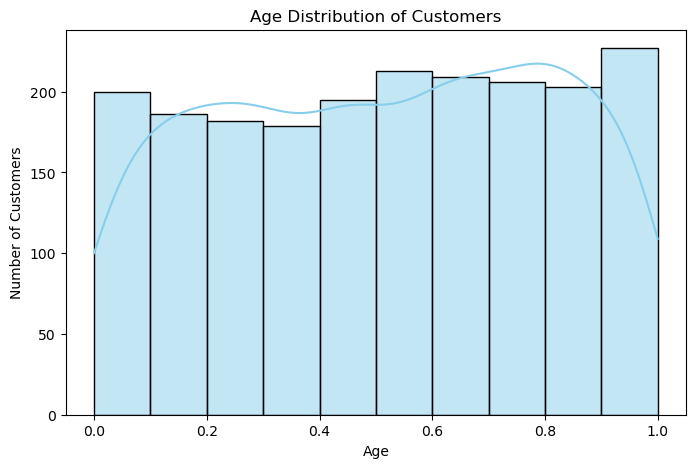

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Age'], bins=10, kde=True, color='skyblue')
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

Gender
1    673
0    664
2    663
Name: count, dtype: int64


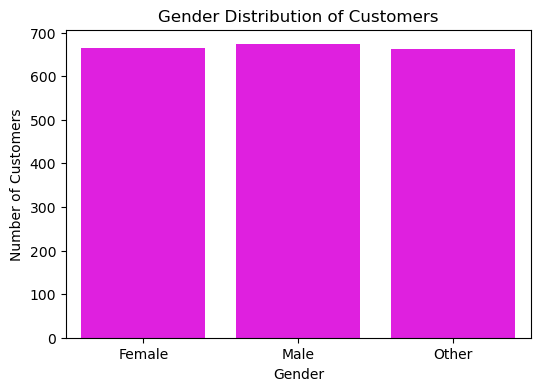

In [22]:
gend_counts = df_clean['Gender'].value_counts()
print(gend_counts)
plt.figure(figsize=(6,4))
sns.barplot(x=gend_counts.index,y=gend_counts.values,color='magenta')
plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.xticks(ticks=[0,1,2], labels=['Female','Male','Other'])
plt.ylabel("Number of Customers")
plt.show()

City_Bengaluru    217
City_Chennai      187
City_Delhi        199
City_Hyderabad    185
City_Jaipur       196
City_Kolkata      196
City_Lucknow      213
City_Mumbai       202
City_Pune         183
dtype: int64

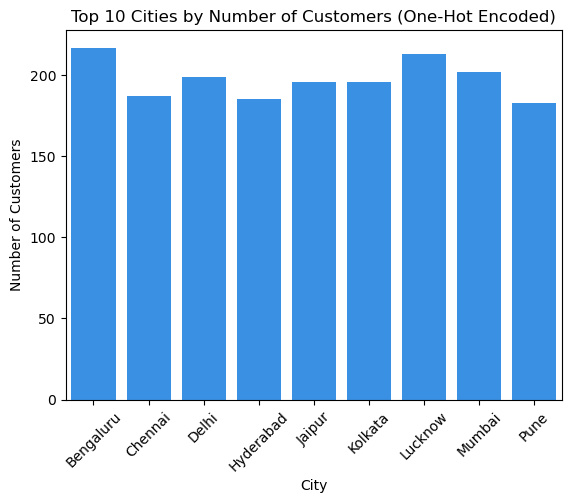

In [23]:
city_columns = [col for col in df_clean.columns if col.startswith('City_')]
city_counts = df_clean[city_columns].sum()
top_cities = city_counts.head(10)
display(top_cities)

sns.barplot(x=top_cities.index.str.replace('City_', ''), y=top_cities.values, color='dodgerblue')
plt.title("Top 10 Cities by Number of Customers (One-Hot Encoded)")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

ProductCategory
Beauty         167.586285
Books          164.765486
Electronics    155.456781
Fashion        142.514819
Furniture      174.315263
Groceries      152.724138
Sports         148.331252
Name: TotalAmount, dtype: float64

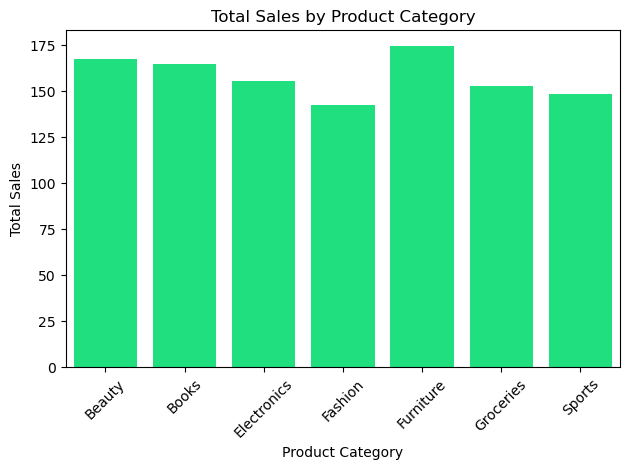

In [24]:
sales_by_category = df_clean.groupby('ProductCategory')['TotalAmount'].sum()
display(sales_by_category)
sns.barplot(x=sales_by_category.index, y=sales_by_category.values,color='springgreen')
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

YearMonth
2023-01     84.973051
2023-02     77.156406
2023-03     95.012592
2023-04     98.665430
2023-05     94.670284
2023-06    102.642477
2023-07     94.747284
2023-08    103.268438
2023-09     90.853028
2023-10     86.826385
2023-11     92.839993
2023-12     81.190731
2024-01      2.847924
Name: TotalAmount, dtype: float64


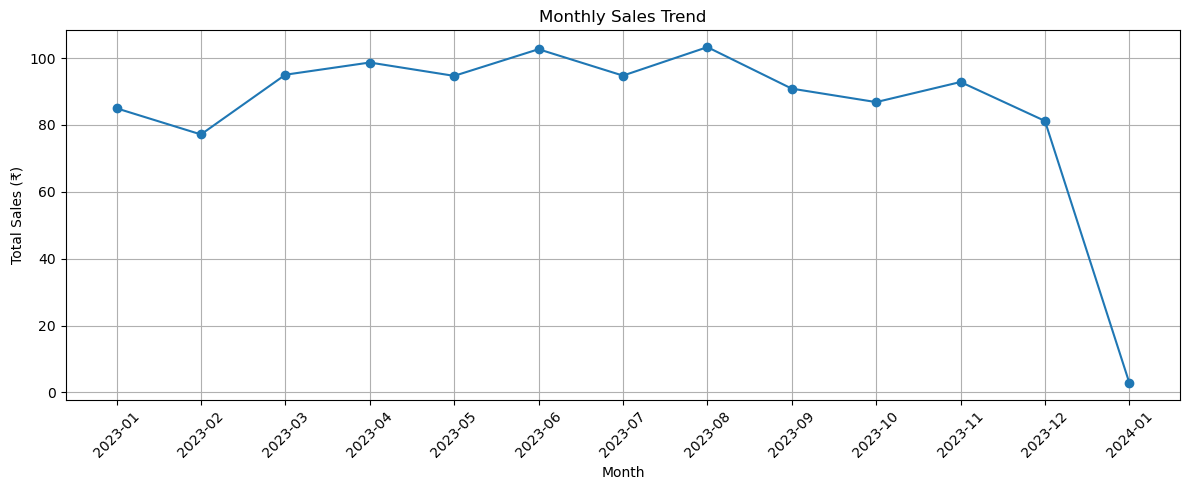

In [25]:
df_clean['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'], errors='coerce')
df_clean['YearMonth'] = df_clean['PurchaseDate'].dt.to_period('M').astype(str)
monthly_trend = (df_clean.groupby('YearMonth')['TotalAmount'].sum().sort_index())
print(monthly_trend)

plt.figure(figsize=(12,5))
plt.plot(monthly_trend.index, monthly_trend.values, marker='o', linestyle='-')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

PaymentMode
Card      520
Wallet    519
UPI       484
Cash      477
Name: count, dtype: int64


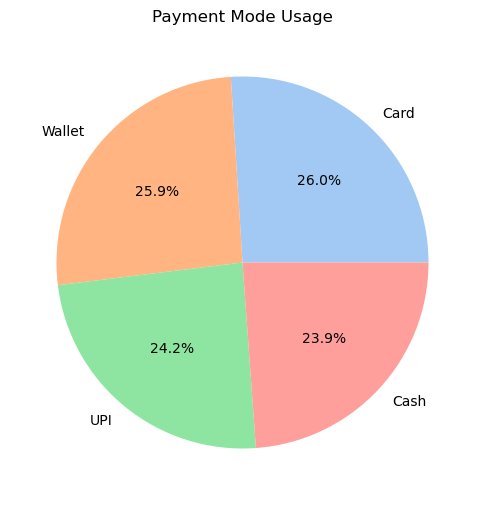

In [26]:
payment_counts = df_clean['PaymentMode'].value_counts()
print(payment_counts)
plt.figure(figsize=(6,8))
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Payment Mode Usage")
plt.show()

AgeGroup
Adult(26-40)          0.557491
Mid Age(41-60)        0.546611
Senior(60+)           0.552047
Young Adult(18-25)    0.562652
Name: TotalAmount, dtype: float64


Text(0, 0.5, 'Average Spend')

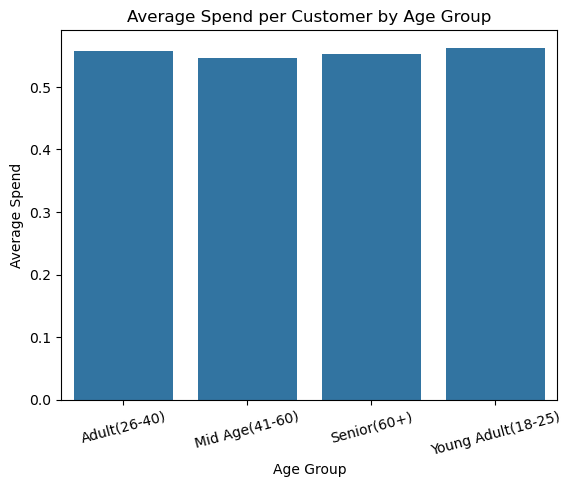

In [27]:
avg_spend_agegroup = df_clean.groupby('AgeGroup',observed=True)['TotalAmount'].mean()
print(avg_spend_agegroup)

sns.barplot(x=avg_spend_agegroup.index, y=avg_spend_agegroup.values)
plt.title('Average Spend per Customer by Age Group')
plt.xlabel('Age Group')
plt.xticks(rotation=15)
plt.ylabel('Average Spend')

City_Bengaluru    117.594357
City_Chennai      105.329440
City_Delhi        112.045291
City_Hyderabad    101.662802
City_Jaipur       105.756682
City_Kolkata      112.144752
City_Lucknow      124.149001
City_Mumbai       105.849898
City_Pune         100.167247
dtype: float64

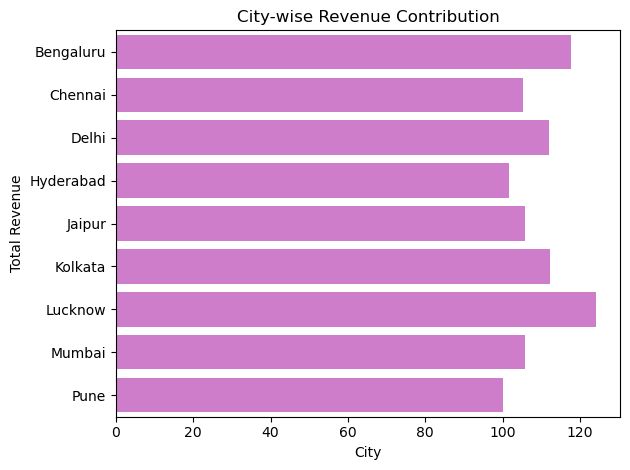

In [28]:
city_columns = [col for col in df_clean.columns if col.startswith('City_')]
city_revenue = (df_clean[city_columns].multiply(df['TotalAmount'], axis=0).sum())
display(city_revenue)

sns.barplot(y=city_revenue.index.str.replace('City_', ''), x=city_revenue.values, color='orchid')
plt.title("City-wise Revenue Contribution")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

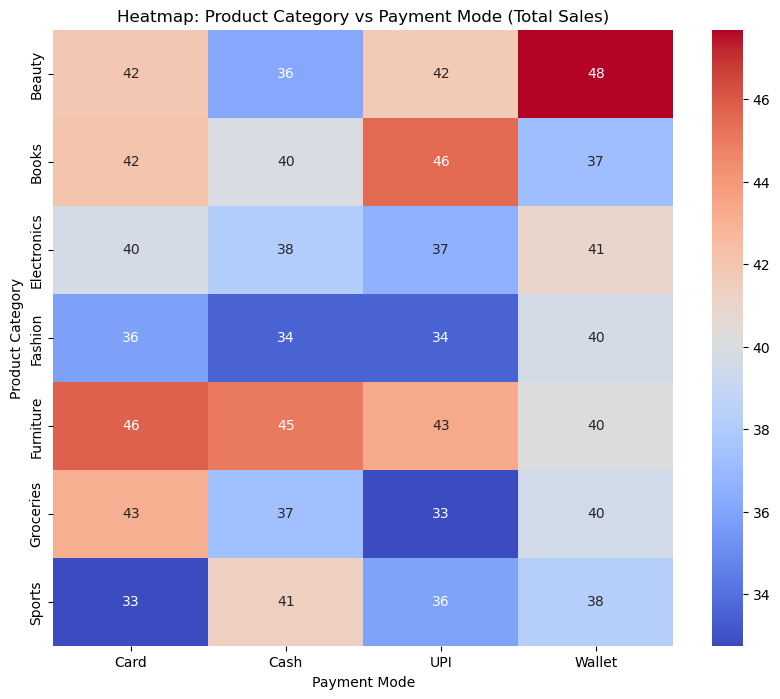

In [29]:
heatmap_data = df_clean.groupby(['ProductCategory', 'PaymentMode'])['TotalAmount'].sum().unstack(fill_value=0)
plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Heatmap: Product Category vs Payment Mode (Total Sales)")
plt.xlabel("Payment Mode")
plt.ylabel("Product Category")
plt.show()